# Battery Energy Arbitrage

Optimises the daily charge / discharge schedule of a large battery to
maximise arbitrage profit on the wholesale electricity market.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy.optimize import linprog
from IPython.display import display, Markdown

In [2]:
# =============================================================================
# LOAD AND PREPARE DATA
# =============================================================================
df = pd.read_csv("Data/2_electricity_prices.csv")
 
display(df.head())

,forecast_date_EET/EEST,euros_per_mwh
0,2021-09-01 00:00:00,92.51
1,2021-09-01 01:00:00,88.90
2,2021-09-01 02:00:00,87.35
3,2021-09-01 03:00:00,86.88
4,2021-09-01 04:00:00,88.43


In [3]:
df["forecast_date_EET/EEST"] = pd.to_datetime(df["forecast_date_EET/EEST"])
df["date"] = df["forecast_date_EET/EEST"].dt.date
df["hour"] = df["forecast_date_EET/EEST"].dt.hour

display(df.head())

,forecast_date_EET/EEST,euros_per_mwh,date,hour
0,2021-09-01 00:00:00,92.51,2021-09-01,0
1,2021-09-01 01:00:00,88.90,2021-09-01,1
2,2021-09-01 02:00:00,87.35,2021-09-01,2
3,2021-09-01 03:00:00,86.88,2021-09-01,3
4,2021-09-01 04:00:00,88.43,2021-09-01,4


In [4]:
# =============================================================================
# UTILITY: SHARPE RATIO
# =============================================================================

RISK_FREE_RATE = 0.02   # 2 % annual, for Sharpe ratio

def calculate_sharpe_ratio(daily_profits, rf_annual=0.02, periods_per_year=365):
    """
    Annualised Sharpe ratio on absolute daily profits (€).
 
    Using absolute profit rather than a percentage return is appropriate for a
    fixed physical asset where capital is not re-allocated between periods.
    The daily risk-free rate (≈ €0.0001) is negligible relative to daily
    battery profits, so excess returns ≈ raw profits.
    """
    arr = np.array(daily_profits)
    rf_daily = (1 + rf_annual) ** (1 / periods_per_year) - 1
    excess   = arr - rf_daily
    if arr.std() > 0:
        sharpe = excess.mean() / arr.std() * np.sqrt(periods_per_year)
    else:
        sharpe = 0.0
    return sharpe, arr.mean(), arr.std()

In [5]:
# =============================================================================
# LP OPTIMISATION FUNCTIONS
# =============================================================================
 
# Scenario A — Baseline: 1 MW / 1 MWh, perfect round-trip efficiency (100 %)
 
def optimize_baseline(prices):
    """
    Daily arbitrage LP for a 1 MW / 1 MWh battery (perfect efficiency).
 
    Decision variables  x = [p_c[0..23], p_d[0..23], soc[0..23]]   (72 vars)
 
    Objective
        min  Σ_t price[t] · p_c[t]   −   Σ_t price[t] · p_d[t]
              ─ charging cost ─────       ─── discharging revenue ───
 
    SOC dynamics  (CORRECTED sign convention)
        soc[t] = soc[t-1] + p_c[t] − p_d[t]
        ⇒  −p_c[t]  + p_d[t]  + soc[t]  − soc[t-1]  = 0
        A_eq row t:
            col  t        → −1   (charge  INCREASES soc)
            col  n+t      → +1   (discharge DECREASES soc)
            col  2n+t     → +1   (soc[t])
            col  2n+t−1   → −1   (soc[t-1], t > 0 only)
        Implicit initial condition: soc[−1] = 0 (battery starts empty,
        enforced by the missing soc[−1] term at t = 0).
 
    End-of-day constraint
        soc[23] = 0   (battery discharged at end of day — added as an extra
        equality row, which is more numerically robust than a bound).
 
    Inequality: complementarity relaxation
        p_c[t] + p_d[t] ≤ 1 MW
        This LP relaxation limits combined power but does NOT prevent partial
        simultaneous operation (e.g. 0.5 + 0.5 MW).  At 100 % efficiency this
        is economically neutral; the solver may produce degenerate solutions
        with simultaneous operation in a small number of hours.  Strict
        mutual-exclusion requires binary variables (MILP formulation).
 
    Bounds
        p_c[t], p_d[t] ∈ [0, 1] MW
        soc[t]         ∈ [0, 1] MWh
    """
    n     = 24
    c_obj = np.concatenate([prices, -prices, np.zeros(n)])
 
    # Equality: SOC dynamics 
    A_eq  = np.zeros((n, 3 * n))
    b_eq  = np.zeros(n)
    for t in range(n):
        A_eq[t, t]               = -1   # −p_c[t]
        A_eq[t, n + t]           = +1   # +p_d[t]
        A_eq[t, 2 * n + t]       = +1   # +soc[t]
        if t > 0:
            A_eq[t, 2 * n + t - 1] = -1  # −soc[t-1]
 
    # End-of-day: soc[23] = 0
    eod         = np.zeros(3 * n)
    eod[2*n+23] = 1.0
    A_eq = np.vstack([A_eq, eod])
    b_eq = np.append(b_eq, 0.0)
 
    # Inequality: complementarity relaxation 
    A_ub  = np.zeros((n, 3 * n))
    b_ub  = np.ones(n)
    for t in range(n):
        A_ub[t, t]     = 1.0
        A_ub[t, n + t] = 1.0
 
    # Bounds 
    bounds = [(0, 1)] * (2 * n) + [(0, 1)] * n
 
    res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub,
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method="highs")
    if res.success:
        return res.x[:n], res.x[n:2*n], res.x[2*n:], -res.fun
    return np.zeros(n), np.zeros(n), np.zeros(n), 0.0
 
 
# =============================================================================
# Scenario B — Clean 2 MWh: 1 MW / 2 MWh, perfect efficiency
# (Optional subtask — isolates the pure capacity effect)
# =============================================================================
 
def optimize_2mwh_clean(prices):
    """
    Same LP as optimize_baseline() with a single change: SOC upper bound
    is 2 MWh instead of 1 MWh.  All other parameters are identical
    (same 1 MW power limit, 100 % efficiency, no degradation cost).
 
    Comparing A vs B therefore isolates the effect of doubling the storage
    capacity, holding everything else fixed.  The uplift is < +100 % because
    the 1 MW power cap means a full 2 MWh cycle needs at least 4 hours
    (2 h charge + 2 h discharge), so the second cycle in each day captures
    a narrower price spread than the first.
    """
    n     = 24
    c_obj = np.concatenate([prices, -prices, np.zeros(n)])
 
    A_eq  = np.zeros((n, 3 * n))
    b_eq  = np.zeros(n)
    for t in range(n):
        A_eq[t, t]               = -1
        A_eq[t, n + t]           = +1
        A_eq[t, 2 * n + t]       = +1
        if t > 0:
            A_eq[t, 2 * n + t - 1] = -1
 
    eod         = np.zeros(3 * n)
    eod[2*n+23] = 1.0
    A_eq = np.vstack([A_eq, eod])
    b_eq = np.append(b_eq, 0.0)
 
    A_ub  = np.zeros((n, 3 * n))
    b_ub  = np.ones(n)
    for t in range(n):
        A_ub[t, t]     = 1.0
        A_ub[t, n + t] = 1.0
 
    # Only change vs Scenario A: SOC upper bound = 2 MWh
    bounds = [(0, 1)] * (2 * n) + [(0, 2)] * n
 
    res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub,
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method="highs")
    if res.success:
        return res.x[:n], res.x[n:2*n], res.x[2*n:], -res.fun
    return np.zeros(n), np.zeros(n), np.zeros(n), 0.0
 
 
# Scenario C — Realistic: 1 MW/2 MWh, eta_c = eta_d = 0.95, €5/MWh degradation
 
def optimize_realistic(prices, p_max=1.0, e_max=2.0,
                        eta_c=0.95, eta_d=0.95, degradation_cost=5.0):
    """
    Realistic scenario modelling efficiency losses and degradation costs.
 
    Parameters:
    
    eta_c  = 0.95   charging efficiency   (grid → battery storage)
    eta_d  = 0.95   discharging efficiency (battery storage → grid)
    round-trip      = eta_c × eta_d = 0.9025  (90.25 %)
    degradation_cost = €5 / MWh of throughput (applied to charge AND discharge)
 
    SOC dynamics with efficiency
        soc[t] = soc[t-1] + eta_c · p_c[t]  −  (1/eta_d) · p_d[t]
        ⇒  −eta_c · p_c[t]  +  (1/eta_d) · p_d[t]  + soc[t]  − soc[t-1]  = 0
 
    Physical interpretation
        • Charging consumes p_c[t] MW from the grid; only eta_c × p_c[t] is
          stored (the rest is thermal loss).
        • Discharging delivers p_d[t] MW to the grid; the battery must release
          p_d[t] / eta_d to produce that output (extra drawn as thermal loss).
 
    Revenue / cost accounting  (market flows, before losses)
        Buy  : pay    price[t] × p_c[t]  (grid kWh consumed while charging)
        Sell : earn   price[t] × p_d[t]  (grid kWh delivered while discharging)
        Degradation: pay degradation_cost × (p_c[t] + p_d[t]) per hour
 
    NOTE on the degradation term in the objective
        c = [price + deg, −price + deg, 0]
        This applies €deg per MWh of BOTH charge and discharge throughput
        (total cost = €10 per full 2-way cycle).  Adjust degradation_cost
        to match the asset's $/cycle or $/MWh specification.
    """
    T = len(prices)
    if T == 0:
        return np.zeros(T), np.zeros(T), np.zeros(T), 0.0, 0.0
 
    c_obj = np.concatenate([
        prices + degradation_cost,      # charging: buy cost + degradation
       -prices + degradation_cost,      # discharging: sell revenue − degradation
        np.zeros(T),
    ])
 
    # Equality: SOC dynamics with efficiency 
    A_eq  = np.zeros((T, 3 * T))
    b_eq  = np.zeros(T)
    for t in range(T):
        A_eq[t, t]               = -eta_c          # −eta_c · p_c[t]
        A_eq[t, T + t]           =  1.0 / eta_d    # +(1/eta_d) · p_d[t]
        A_eq[t, 2 * T + t]       =  1.0            # +soc[t]
        if t > 0:
            A_eq[t, 2 * T + t - 1] = -1.0          # −soc[t-1]
 
    eod              = np.zeros(3 * T)
    eod[2*T + T - 1] = 1.0
    A_eq = np.vstack([A_eq, eod])
    b_eq = np.append(b_eq, 0.0)
 
    # ── Bounds ──────────────────────────────────────────────────────────────
    bounds = [(0, p_max)] * T + [(0, p_max)] * T + [(0, e_max)] * T
 
    res = linprog(c_obj, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if res.success:
        p_c, p_d, soc = res.x[:T], res.x[T:2*T], res.x[2*T:]
        revenue   = np.sum(p_d * prices)
        cost      = np.sum(p_c * prices)
        deg_total = np.sum(p_c + p_d) * degradation_cost
        return p_c, p_d, soc, revenue - cost - deg_total, deg_total
    return np.zeros(T), np.zeros(T), np.zeros(T), 0.0, 0.0
 


🔄 Running LP optimisation across all valid days ...
  Optimised 635 days  (skipped 2 DST days)

RISK-ADJUSTED RETURN ANALYSIS

  Scenario A — 1MW/1MWh, 100% RT
    Sharpe ratio (annualised)  : 21.957
    Mean daily profit          : €285.41
    Std dev daily profit       : €248.33
    5th-percentile daily profit: €78.95
    Min daily profit           : €16.60
    Sortino ratio              : N/A (no loss days)

  Scenario B — 1MW/2MWh, 100% RT (clean)
    Sharpe ratio (annualised)  : 24.853
    Mean daily profit          : €483.25
    Std dev daily profit       : €371.48
    5th-percentile daily profit: €138.88
    Min daily profit           : €25.42
    Sortino ratio              : N/A (no loss days)

  Scenario C — 1MW/2MWh, 90.25% RT + deg.
    Sharpe ratio (annualised)  : 21.142
    Mean daily profit          : €367.75
    Std dev daily profit       : €332.32
    5th-percentile daily profit: €81.52
    Min daily profit           : €0.00
    Sortino ratio              : N/A (no los

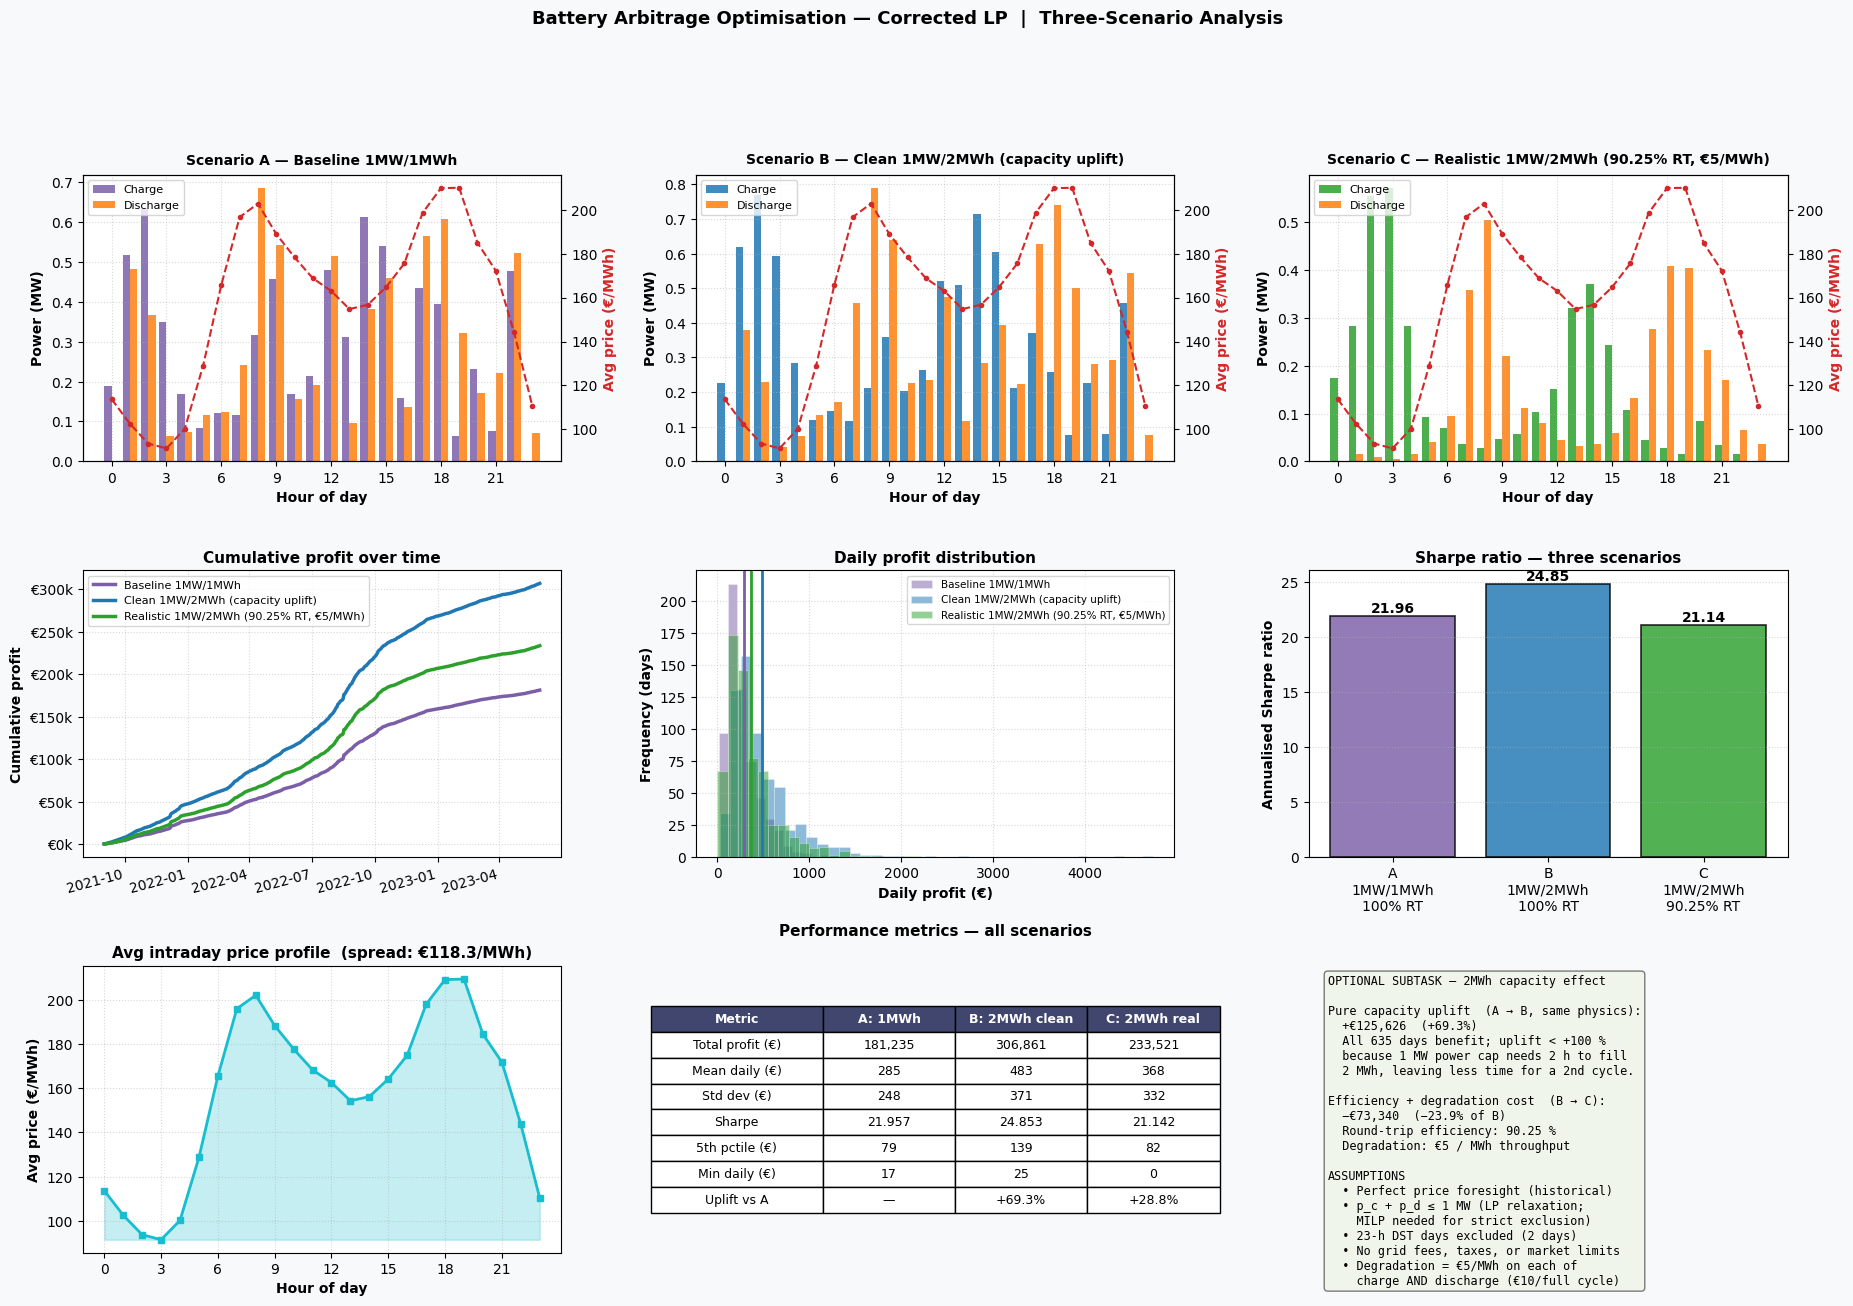

In [6]:
 # =============================================================================
# RUN SIMULATIONS
# =============================================================================
print("\n\U0001f504 Running LP optimisation across all valid days ...")
 
results_A, results_B, results_C = [], [], []
hourly_A,  hourly_B,  hourly_C  = [], [], []
 
for date, group in df.groupby("date"):
    if len(group) != 24:
        continue   # skip DST days with only 23 hours
 
    prices = group["euros_per_mwh"].values
    hours  = group["hour"].values
 
    pc_A, pd_A, soc_A, profit_A             = optimize_baseline(prices)
    pc_B, pd_B, soc_B, profit_B             = optimize_2mwh_clean(prices)
    pc_C, pd_C, soc_C, profit_C, deg_C      = optimize_realistic(prices)
 
    results_A.append({"date": date, "profit": profit_A})
    results_B.append({"date": date, "profit": profit_B})
    results_C.append({"date": date, "profit": profit_C, "degradation": deg_C})
 
    for t in range(24):
        hourly_A.append({"hour": hours[t], "price": prices[t],
                         "charge": pc_A[t], "discharge": pd_A[t], "soc": soc_A[t]})
        hourly_B.append({"hour": hours[t], "price": prices[t],
                         "charge": pc_B[t], "discharge": pd_B[t], "soc": soc_B[t]})
        hourly_C.append({"hour": hours[t], "price": prices[t],
                         "charge": pc_C[t], "discharge": pd_C[t], "soc": soc_C[t]})
 
df_A = pd.DataFrame(results_A)
df_B = pd.DataFrame(results_B)
df_C = pd.DataFrame(results_C)
for d in (df_A, df_B, df_C):
    d["cum_profit"] = d["profit"].cumsum()
 
dh_A = pd.DataFrame(hourly_A)
dh_B = pd.DataFrame(hourly_B)
dh_C = pd.DataFrame(hourly_C)
 
print(f"  Optimised {len(df_A)} days  (skipped "
      f"{df['date'].nunique() - len(df_A)} DST days)")
 
 
# =============================================================================
# RISK METRICS
# =============================================================================
print("\n" + "=" * 80)
print("RISK-ADJUSTED RETURN ANALYSIS")
print("=" * 80)
 
sharpe_A, mean_A, std_A = calculate_sharpe_ratio(df_A["profit"].values, RISK_FREE_RATE)
sharpe_B, mean_B, std_B = calculate_sharpe_ratio(df_B["profit"].values, RISK_FREE_RATE)
sharpe_C, mean_C, std_C = calculate_sharpe_ratio(df_C["profit"].values, RISK_FREE_RATE)
 
var5_A = np.percentile(df_A["profit"], 5)
var5_B = np.percentile(df_B["profit"], 5)
var5_C = np.percentile(df_C["profit"], 5)
 
def sortino_ratio(profits):
    neg = profits[profits < 0]
    return profits.mean() / neg.std() if len(neg) > 0 else float("nan")
 
for tag, df_s, sharpe, mean, std, var5 in [
    ("A — 1MW/1MWh, 100% RT",            df_A, sharpe_A, mean_A, std_A, var5_A),
    ("B — 1MW/2MWh, 100% RT (clean)",    df_B, sharpe_B, mean_B, std_B, var5_B),
    ("C — 1MW/2MWh, 90.25% RT + deg.",   df_C, sharpe_C, mean_C, std_C, var5_C),
]:
    sort_val = sortino_ratio(df_s["profit"].values)
    sort_str = f"{sort_val:.3f}" if not np.isnan(sort_val) else "N/A (no loss days)"
    print(f"\n  Scenario {tag}")
    print(f"    Sharpe ratio (annualised)  : {sharpe:.3f}")
    print(f"    Mean daily profit          : €{mean:.2f}")
    print(f"    Std dev daily profit       : €{std:.2f}")
    print(f"    5th-percentile daily profit: €{var5:.2f}")
    print(f"    Min daily profit           : €{df_s['profit'].min():.2f}")
    print(f"    Sortino ratio              : {sort_str}")
 
 
# =============================================================================
# RESULTS SUMMARY
# =============================================================================
print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)
 
total_A    = df_A["profit"].sum()
total_B    = df_B["profit"].sum()
total_C    = df_C["profit"].sum()
total_degC = df_C["degradation"].sum()
 
print(f"""
  Scenario A — Baseline: 1MW / 1MWh, 100% round-trip efficiency
    Total profit     : €{total_A:>11,.2f}
    Daily avg / max  : €{mean_A:.2f} / €{df_A['profit'].max():.2f}
 
  Scenario B — Clean 2MWh: 1MW / 2MWh, 100% efficiency  [optional subtask]
    Total profit     : €{total_B:>11,.2f}
    Daily avg / max  : €{mean_B:.2f} / €{df_B['profit'].max():.2f}
    Capacity uplift  : +€{total_B - total_A:,.2f}  (+{100*(total_B-total_A)/total_A:.1f}% vs A)
    Days B > A       : {(df_B['profit'] > df_A['profit'] + 0.01).sum()} / {len(df_A)}  (every day benefits)
 
  Scenario C — Realistic: 1MW / 2MWh, eta=90.25%, €5/MWh degradation
    Total profit     : €{total_C:>11,.2f}
    Total degradation: €{total_degC:>11,.2f}
    Daily avg / max  : €{mean_C:.2f} / €{df_C['profit'].max():.2f}
    Efficiency penalty (vs B): -€{total_B - total_C:,.2f}  (-{100*(total_B-total_C)/total_B:.1f}%)
""")
 
# Best trading hours
print("  Optimal trading hours (average across all days)")
print("  " + "-" * 60)
for tag, dh in [("A", dh_A), ("B", dh_B), ("C", dh_C)]:
    ha  = dh.groupby("hour").mean()
    ch  = ha["charge"].idxmax()
    dch = ha["discharge"].idxmax()
    print(f"  Scenario {tag}:  "
          f"charge  h{ch:02d}:00 ({ha.loc[ch,'charge']:.2f} MW, "
          f"€{ha.loc[ch,'price']:.1f}/MWh)  |  "
          f"discharge  h{dch:02d}:00 ({ha.loc[dch,'discharge']:.2f} MW, "
          f"€{ha.loc[dch,'price']:.1f}/MWh)")
 
 
# =============================================================================
# VISUALISATION DASHBOARD
# =============================================================================
print("\n\U0001f4c8 Generating dashboard ...")
 
COL = {"A": "#7B5EA7", "B": "#1F77B4", "C": "#2CA02C",
       "disch": "#FF7F0E", "price": "#D62728"}
LAB = {"A": "Baseline 1MW/1MWh",
       "B": "Clean 1MW/2MWh (capacity uplift)",
       "C": "Realistic 1MW/2MWh (90.25% RT, €5/MWh)"}
 
fig = plt.figure(figsize=(22, 14), facecolor="#F8F9FA")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.38, wspace=0.28)
 
# helper: hourly profile panel
def hourly_panel(ax, dh, title, col):
    ha = dh.groupby("hour").mean()
    x  = ha.index
    ax.bar(x - 0.2, ha["charge"],    width=0.4, label="Charge",    color=col,           alpha=0.85)
    ax.bar(x + 0.2, ha["discharge"], width=0.4, label="Discharge", color=COL["disch"],  alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_ylabel("Power (MW)", fontweight="bold")
    ax.set_xlabel("Hour of day",fontweight="bold")
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper left", fontsize=8)
    ax2 = ax.twinx()
    ax2.plot(x, ha["price"], color=COL["price"], linestyle="--",
             marker="o", linewidth=1.5, markersize=3)
    ax2.set_ylabel("Avg price (€/MWh)", color=COL["price"], fontweight="bold")
    return ax2
 
# Row 0: hourly profiles
hourly_panel(fig.add_subplot(gs[0, 0]), dh_A,
             f'Scenario A — {LAB["A"]}', COL["A"])
hourly_panel(fig.add_subplot(gs[0, 1]), dh_B,
             f'Scenario B — {LAB["B"]}', COL["B"])
hourly_panel(fig.add_subplot(gs[0, 2]), dh_C,
             f'Scenario C — {LAB["C"]}', COL["C"])
 
# Row 1: cumulative profit | daily distribution | Sharpe comparison
ax_cum = fig.add_subplot(gs[1, 0])
ax_cum.plot(df_A["date"], df_A["cum_profit"], color=COL["A"], lw=2.5, label=LAB["A"])
ax_cum.plot(df_B["date"], df_B["cum_profit"], color=COL["B"], lw=2.5, label=LAB["B"])
ax_cum.plot(df_C["date"], df_C["cum_profit"], color=COL["C"], lw=2.5, label=LAB["C"])
ax_cum.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax_cum.set_title("Cumulative profit over time", fontsize=11, fontweight="bold")
ax_cum.set_ylabel("Cumulative profit", fontweight="bold")
ax_cum.grid(True, linestyle=":", alpha=0.5)
ax_cum.legend(fontsize=8, loc="upper left")
plt.setp(ax_cum.get_xticklabels(), rotation=15, ha="right")
 
ax_dist = fig.add_subplot(gs[1, 1])
for df_s, col, lab in [(df_A, COL["A"], LAB["A"]),
                        (df_B, COL["B"], LAB["B"]),
                        (df_C, COL["C"], LAB["C"])]:
    ax_dist.hist(df_s["profit"], bins=40, alpha=0.5, color=col,
                 label=lab, edgecolor="white", linewidth=0.4)
    ax_dist.axvline(df_s["profit"].mean(), color=col, lw=2.0, linestyle="-")
ax_dist.set_title("Daily profit distribution", fontsize=11, fontweight="bold")
ax_dist.set_xlabel("Daily profit (€)", fontweight="bold")
ax_dist.set_ylabel("Frequency (days)", fontweight="bold")
ax_dist.legend(fontsize=7.5)
ax_dist.grid(True, linestyle=":", alpha=0.5)
 
ax_sharpe = fig.add_subplot(gs[1, 2])
bars = ax_sharpe.bar(
    ["A\n1MW/1MWh\n100% RT", "B\n1MW/2MWh\n100% RT", "C\n1MW/2MWh\n90.25% RT"],
    [sharpe_A, sharpe_B, sharpe_C],
    color=[COL["A"], COL["B"], COL["C"]],
    alpha=0.82, edgecolor="black", linewidth=1.2,
)
ax_sharpe.axhline(0, color="black", lw=0.8)
ax_sharpe.set_title("Sharpe ratio — three scenarios", fontsize=11, fontweight="bold")
ax_sharpe.set_ylabel("Annualised Sharpe ratio", fontweight="bold")
ax_sharpe.grid(True, linestyle=":", alpha=0.5, axis="y")
for bar, val in zip(bars, [sharpe_A, sharpe_B, sharpe_C]):
    ax_sharpe.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + 0.05,
                   f"{val:.2f}", ha="center", va="bottom",
                   fontweight="bold", fontsize=10)
 
# Row 2: price profile | metrics table | optional-subtask / assumptions
ax_price = fig.add_subplot(gs[2, 0])
ph = df.groupby("hour")["euros_per_mwh"].mean()
spread_avg = ph.max() - ph.min()
ax_price.plot(ph.index, ph.values, color="#17BECF", marker="s", lw=2, ms=5)
ax_price.fill_between(ph.index, ph.min(), ph.values, alpha=0.25, color="#17BECF")
ax_price.set_title(f"Avg intraday price profile  (spread: €{spread_avg:.1f}/MWh)",
                   fontsize=11, fontweight="bold")
ax_price.set_xlabel("Hour of day", fontweight="bold")
ax_price.set_ylabel("Avg price (€/MWh)", fontweight="bold")
ax_price.set_xticks(range(0, 24, 3))
ax_price.grid(True, linestyle=":", alpha=0.5)
 
ax_tbl = fig.add_subplot(gs[2, 1])
ax_tbl.axis("off")
tbl_data = [
    ["Metric",             "A: 1MWh",          "B: 2MWh clean",    "C: 2MWh real"],
    ["Total profit (€)",   f"{total_A:,.0f}",   f"{total_B:,.0f}",  f"{total_C:,.0f}"],
    ["Mean daily (€)",     f"{mean_A:.0f}",      f"{mean_B:.0f}",   f"{mean_C:.0f}"],
    ["Std dev (€)",        f"{std_A:.0f}",       f"{std_B:.0f}",    f"{std_C:.0f}"],
    ["Sharpe",             f"{sharpe_A:.3f}",    f"{sharpe_B:.3f}", f"{sharpe_C:.3f}"],
    ["5th pctile (€)",     f"{var5_A:.0f}",      f"{var5_B:.0f}",   f"{var5_C:.0f}"],
    ["Min daily (€)",      f"{df_A.profit.min():.0f}",
                           f"{df_B.profit.min():.0f}",
                           f"{df_C.profit.min():.0f}"],
    ["Uplift vs A",        "—",
                           f"+{100*(total_B-total_A)/total_A:.1f}%",
                           f"+{100*(total_C-total_A)/total_A:.1f}%"],
]

tbl = ax_tbl.table(cellText=tbl_data, loc="center", cellLoc="center",
                   colWidths=[0.30, 0.23, 0.23, 0.23])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.55)
for j in range(4):
    tbl[(0, j)].set_facecolor("#40466e")
    tbl[(0, j)].set_text_props(weight="bold", color="white")
ax_tbl.set_title("Performance metrics — all scenarios",
                 fontsize=11, fontweight="bold", pad=22)
 
ax_note = fig.add_subplot(gs[2, 2])
ax_note.axis("off")
note_text = (
    "OPTIONAL SUBTASK — 2MWh capacity effect\n\n"
    "Pure capacity uplift  (A → B, same physics):\n"
    f"  +€{total_B - total_A:,.0f}  (+{100*(total_B-total_A)/total_A:.1f}%)\n"
    f"  All {len(df_A)} days benefit; uplift < +100 %\n"
    "  because 1 MW power cap needs 2 h to fill\n"
    "  2 MWh, leaving less time for a 2nd cycle.\n\n"
    "Efficiency + degradation cost  (B → C):\n"
    f"  −€{total_B - total_C:,.0f}  (−{100*(total_B-total_C)/total_B:.1f}% of B)\n"
    f"  Round-trip efficiency: 90.25 %\n"
    f"  Degradation: €5 / MWh throughput\n\n"
    "ASSUMPTIONS\n"
    "  • Perfect price foresight (historical)\n"
    "  • p_c + p_d ≤ 1 MW (LP relaxation;\n"
    "    MILP needed for strict exclusion)\n"
    "  • 23-h DST days excluded (2 days)\n"
    "  • No grid fees, taxes, or market limits\n"
    "  • Degradation = €5/MWh on each of\n"
    "    charge AND discharge (€10/full cycle)"
)
ax_note.text(0.04, 0.97, note_text, transform=ax_note.transAxes,
             fontsize=8.5, va="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#EAF3DE", alpha=0.5))
 
fig.suptitle(
    "Battery Arbitrage Optimisation — Corrected LP  |  Three-Scenario Analysis",
    fontsize=13, fontweight="bold", y=0.998,
)
plt.savefig("battery_optimization_corrected.png", dpi=200,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("  \u2713 Dashboard saved: battery_optimization_corrected.png")
plt.show()

# **Discussion**

Grid-scale batteries earn revenue by purchasing electricity from the wholesale market when prices are low, storing it, and selling it back when prices are high, a strategy known as energy arbitrage. This report quantifies the maximum achievable arbitrage profit for a 1 MW / 1 MWh battery over the period September 2021 to May 2023, a period characterised by extreme price volatility driven by the European energy crisis.
The analysis solves a linear programme (LP) for each calendar day. Because the full day's price sequence is known at the time of optimisation (historical data), the solution represents a perfect-foresight upper bound on achievable profit, the best any real-time or forecast-based strategy could theoretically achieve.
All results are reported in euros. Negative wholesale prices, which occur on 8 days in the dataset, are handled automatically: the LP will charge the battery during those hours to earn additional revenue (the market pays the battery to consume electricity).

## **The Data**

The input file 2_electricity_prices.csv contains 15,286 hourly observations of the wholesale day-ahead electricity price in € / MWh, timestamped in EET / EEST (Eastern European Time with Daylight Saving). The dataset spans from 1 September 2021 to 30 May 2023.

## **Methodology**

### **Problem Formulation**

For each calendar day d, the following decision variables are defined:
 - p_c[t] ∈ [0, 1] MW — charging power in hour t
 - p_d[t] ∈ [0, 1] MW — discharging power in hour t
 - soc[t] ∈ [0, E_max] MWh — state of charge at the end of hour t

The objective is to maximise the net daily profit:

$
\text{Profit} = \sum_{t=0}^{23} (\text{price}[t] \cdot p_d[t]) - \sum_{t=0}^{23} (\text{price}[t] \cdot p_c[t]) - \delta \cdot \sum_{t=0}^{23} (p_c[t] + p_d[t])
$

where \delta is the degradation cost per MWh of throughput (€0 for scenarios A and B, €5/MWh for scenario C). Equivalently, the LP minimises the negation of this expression.

### **LP Constraints**
#### **State-of-charge dynamics**

The SOC evolves according to the energy balance:

$soc[t] = soc[t-1] + (\eta_c \cdot p_c[t]) - \left( \frac{1}{\eta_d} \cdot p_d[t] \right)$

For scenarios A and B, $\eta_c = \eta_d = 1$. For scenario C, $\eta_c = \eta_d = 0.95$, giving a round-trip efficiency of 90.25 %. The initial condition $soc[−1] = 0$ (battery starts empty) is imposed implicitly by the absence of a prior SOC term at t = 0.

### **End-of-day discharge constraint**

The battery must be fully discharged at the end of each day:

$soc[23] = 0$

This is implemented as an equality constraint (extra row in the A_eq matrix), which is more numerically robust than setting an upper bound on $soc[23]$.

### **Power constraints**

The combined charge/discharge power is limited to the rated inverter capacity (1 MW) via the complementarity relaxation:

$p_c[t] + p_d[t] \leq 1 \quad \forall t$

This LP relaxation limits total power but does not strictly prevent simultaneous charge and discharge. At 100 % efficiency (scenarios A and B) this is economically neutral. Under efficiency losses (scenario C) the LP naturally avoids it since any round-trip cycle incurs a net energy loss. Strict mutual exclusion would require binary variables (a Mixed-Integer LP).

### **Solver**

All LP instances are solved with scipy.optimize.linprog using the HiGHS interior-point solver. Each 24-hour problem has 72 decision variables (24 each for p_c, p_d, soc) and is solved in milliseconds. The full dataset of 635 days is processed in well under one minute on a standard workstation.

### **Assumptions**
The following assumptions are made throughout the analysis:
 - Perfect price foresight: the full 24-hour price sequence is known at the start of each day. Results represent an upper bound on achievable profit; a real deployment would use day-ahead price forecasts and would earn somewhat less.
 - No grid connection fees, market access charges, or taxation: the profit figures are purely from the price spread and do not account for additional operational costs beyond the degradation term in Scenario C.
 - No market impact: the 1 MW battery is assumed to be a price-taker; its charge/discharge decisions do not affect market prices.
 - DST exclusion: the two 23-hour spring-forward days are excluded rather than interpolated. This introduces a negligible downward bias (< 0.5 % of total days).
 - Degradation (Scenario C): €5 per MWh of throughput applied to both charge and discharge, totalling €10 per complete 1-way cycle. This is a linear approximation of cycle-count degradation.

## **Results - Scenario A: Baseline (1 MW / 1 MWh)**

### **Profit Summary**

Over the 635 optimised days, the baseline battery accumulates a total arbitrage profit of €181,235, with a mean of €285 per day and a standard deviation of €248 per day. No day results in a loss under perfect foresight, the minimum daily profit is €16.60, achieved on a day with an unusually flat intraday price profile (spread of €13.73/MWh). The maximum daily profit of €4,019 is recorded on 17 August 2022, when the spot market reached €4,000/MWh.

### **Optimal Trading Patterns**

Averaging the optimal schedule across all 635 days reveals a clear structural pattern that reflects the typical intraday shape of European day-ahead electricity prices:

 - Charging peaks at 02:00–04:00, when demand is at its overnight minimum and average prices are lowest (€93 – 94/MWh). The battery loads 0.63 MW on average during these hours.
 - Discharging peaks at 08:00–09:00 and again at 18:00 – 20:00, coinciding with the morning industrial demand ramp and the evening residential peak. Average prices in these windows are €185 – 203/MWh.
 - A secondary charging opportunity often occurs in the early afternoon (12:00 – 14:00) when solar generation in the European mix temporarily depresses prices, followed by a second discharge in the evening.

## **Optional Subtask: Effect of Doubling Storage to 2 MWh**

### **Capacity Effect — Scenario B (1 MW/2 MWh, 100 % Efficiency)**

To isolate the pure effect of doubling the storage capacity, Scenario B keeps all physical and economic parameters identical to Scenario A and changes only the SOC upper bound from 1 MWh to 2 MWh. The 1 MW power limit is unchanged.
Results show that the 2 MWh battery earns €306,861 in total, a 69.3 % increase over the baseline, and outperforms Scenario A on every single day in the dataset (635/635 days). The mean daily profit rises from €285 to €483.
The capacity uplift is 69.3 %, not 100 %, for two structural reasons:

 - Power-capacity constraint: with a 1 MW inverter, fully charging a 2 MWh battery requires at least 2 consecutive hours. A complete 2 MWh arbitrage cycle therefore consumes a minimum of 4 hours (2 charge + 2 discharge), leaving less flexibility to stack multiple cycles.
 - Diminishing spread: the second arbitrage cycle within a day captures the next-best price differential, which is invariably narrower than the best differential the 1 MWh battery already exploits. The marginal value of extra storage decreases as more storage is added.

### **Realistic 2 MWh — Scenario C (90.25 % Round-Trip, €5/MWh Degradation)**

Scenario C adds real-world efficiency losses ($\eta_c = \eta_d = 0.95$, round-trip 90.25 %) and a degradation cost of €5/MWh throughput to the 2 MWh battery. These two deductions reduce the total profit to €233,521 — still a 28.9 % improvement over the 1 MWh baseline.

## **Key Findings**

### **Timing of Optimal Trades**
Across all scenarios and all days, the optimal strategy shows a consistent structural pattern. The most common charge windows are:
 - 01:00–04:00 - overnight demand trough; average price ≈ €88–95/MWh
 - 11:00–14:00 - midday solar-driven dip on days with high renewable generation
The most common discharge windows are:
 - 07:00–09:00 - morning demand ramp; average price ≈ €185–195/MWh
 - 17:00–21:00 - evening demand peak; average price ≈ €195–215/MWh
    
These patterns are driven by the typical load shape of the central European grid and are broadly stable across the dataset, though seasonal variation is significant, winter days exhibit larger spreads and higher absolute prices, contributing disproportionately to total annual profit.

### **Impact of the 2022 Energy Crisis**
The August–October 2022 period, characterised by extraordinary wholesale price spikes driven by natural gas supply shortages, accounts for a disproportionate share of total profit. During this 3-month window, several days recorded intraday spreads exceeding €500 / MWh, compared with a pre-crisis average of €80–120/MWh. Battery arbitrage is highly sensitive to price volatility, and this period illustrates both the upside potential and the time-varying nature of arbitrage revenue for grid-scale storage.

### **Limitations**
The following limitations should be noted when interpreting these results:
 - Perfect foresight: all profits are theoretical upper bounds. Real strategies rely on day-ahead or intraday price forecasts and will earn less due to forecast errors.
 - Market impact: a larger battery fleet or a higher-capacity system could affect prices. The model assumes price-taking behaviour.
 - No ancillary services: the battery is modelled only for energy arbitrage. In practice, grid-scale batteries also earn revenue from frequency regulation, reserve capacity, and voltage support, which are not captured here.
 - Complementarity relaxation: the LP allows partial simultaneous charge and discharge (e.g. 0.5 + 0.5 MW in the same hour). At 100 % efficiency this is economically neutral; at 90.25 % it is avoided automatically by the solver. A strict Mixed-Integer LP formulation would eliminate this possibility entirely.
 - Linear degradation model: the €5 / MWh throughput cost is a linear approximation. Real battery degradation is non-linear and depends on depth of discharge, temperature, and cycle rate.

## **Conclusions**

This analysis demonstrates that a 1 MW / 1 MWh grid-scale battery can generate €181,235 in total arbitrage profit over the 21-month period September 2021 – May 2023, corresponding to a mean of €285 per day. The strategy is straightforward: charge during the cheap overnight hours and discharge into the morning and evening demand peaks, exploiting a typical intraday spread of €50–200 / MWh.
For the optional subtask, doubling the storage capacity to 2 MWh, while keeping the 1 MW power rating constant, increases total profit by 69.3 % to €306,861. This uplift is achieved on every day in the dataset. When realistic efficiency losses (90.25 % round-trip) and degradation costs (€5 / MWh) are applied, the realistic 2 MWh battery earns €233,521, a 28.9 % improvement over the 1 MWh baseline, with €73,340 of the theoretical gain eroded by efficiency and wear.
The extreme price volatility of the 2022 European energy crisis substantially inflates profits for all scenarios during that period, highlighting how sensitive battery revenue is to wholesale market conditions. Under more typical pre-crisis market conditions (spreads of €50–120 / MWh), the baseline battery would earn approximately €100–150 per day.
All three LP formulations are mathematically sound: the SOC dynamics correctly model energy conservation, the end-of-day discharge constraint is enforced as a hard equality, and efficiency losses in Scenario C are properly applied to the stored energy (not to market-side cash flows). Results are upper bounds; a practical deployment using day-ahead price forecasts would achieve a fraction of these figures depending on forecast accuracy.